# Analiza Intenției de Cumpărare Online prin Arbori de Decizie


## Descrierea Proiectului

Acest proiect aplică tehnici de **clasificare bazate pe arbori de decizie** pentru a analiza și prezice intenția de cumpărare a vizitatorilor unui site de e-commerce. Folosind datele de sesiune ale utilizatorilor, modelele construite identifică **pattern-uri comportamentale** care diferențiază vizitatorii care finalizează o achiziție de cei care nu o fac.

## Obiectiv

Variabila țintă este **`Revenue`** (calitativă, binară: `TRUE` / `FALSE`), care indică dacă o sesiune de navigare s-a finalizat cu o tranzacție comercială.

Scopul principal este construirea unor modele predictive capabile să clasifice corect intenția de cumpărare pe baza caracteristicilor comportamentale și tehnice ale sesiunii.

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
os.getcwd()

'/home/matei/Financial-Fraud-Detection/notebooks/OnlinePurchasing'

In [32]:
path_to_dataset = '../../data/raw/online_shoppers_intention_recoded.csv'

if not os.path.isfile(path_to_dataset):
    print("no good")
else:
    df = pd.read_csv(path_to_dataset)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  str    
 12  Browser                  12330 non-null  str    
 13  Region                   12330 non-null  str    
 14  TrafficType              12330 no

In [34]:
df.shape

(12330, 18)

-   Dimensiune: 12.330 înregistrări (linii), 18 variabile(coloane)

-   Sursă: UCI Machine Learning Repository / Kaggle.

-   Perioadă: Date colectate pe parcursul unui an pentru a evita bias-ul de sezonalitate (deși lipsesc Ianuarie și Aprilie).

## EDA

-   Valori lipsa

-   Valori unice

In [35]:
df.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              5
Browser                       9
Region                        9
TrafficType                  12
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [36]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

-   Duplicate

In [37]:
df.duplicated().sum()

np.int64(125)

In [38]:
df.shape[0]

12330

In [39]:
df = df.drop_duplicates()
df.shape[0]

12205

In [40]:

print(f"VisitorType valori: {df['VisitorType'].unique()}")
print(f"Weekend valori: {df['Weekend'].unique()}")
print(f"Revenue valori: {df['Revenue'].unique()}")
print(f"Month valori: {sorted(df['Month'].unique())}")

VisitorType valori: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str
Weekend valori: [False  True]
Revenue valori: [False  True]
Month valori: ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


-   Obs: lipsesc Aprilie si Ianuarie

## Analiza nebalansarii claselor

In [41]:
df['Revenue'].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

In [42]:
counts = df['Revenue'].value_counts()
pcts = df['Revenue'].value_counts(normalize=True) * 100
 
print(f"Clasa FALSE (nu cumpără): {counts[False]:>6,} -> {pcts[False]:.2f}%")
print(f"Clasa TRUE (cumpără): {counts[True]:>6,} -> {pcts[True]:.2f}%")
print(f"Raport dezechilibru : {counts[False]/counts[True]:.1f} : 1")

Clasa FALSE (nu cumpără): 10,297 -> 84.37%
Clasa TRUE (cumpără):  1,908 -> 15.63%
Raport dezechilibru : 5.4 : 1


-   BD este nebalansata: clasa majoritara depaseste cu mult pe cea minoritara cu un raport de aprox 5.5:1. Dezechilibru mare, care poate duce la modele care clasifica tot ca FALSE si totusi obtine acuratete mare, de sa zicem 84%

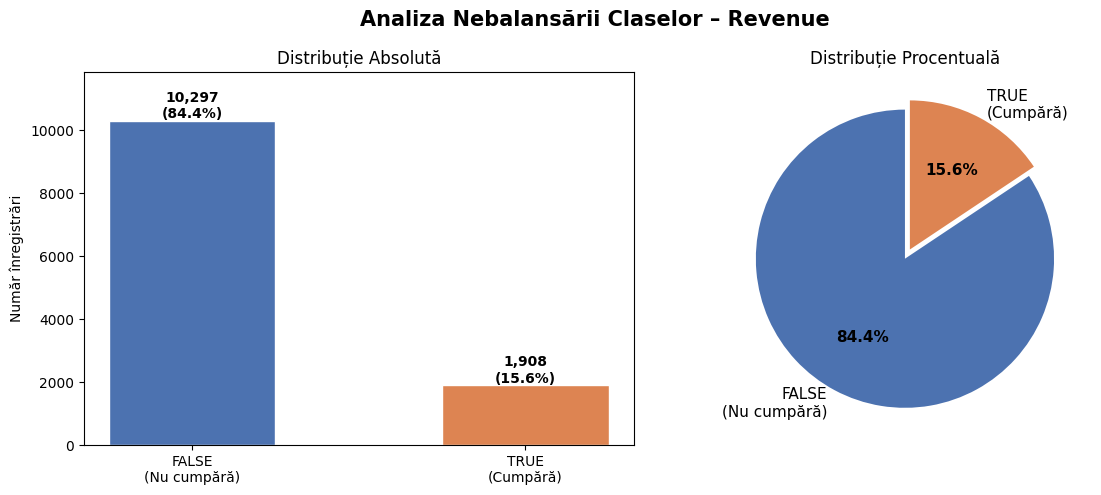

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Analiza Nebalansării Claselor – Revenue', fontsize=15, fontweight='bold')
colors = ['#4C72B0', '#DD8452']

axes[0].bar(['FALSE\n(Nu cumpără)', 'TRUE\n(Cumpără)'],
            [counts[False], counts[True]],
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Distribuție Absolută', fontsize=12)
axes[0].set_ylabel('Număr înregistrări')
for i, (v, p) in enumerate(zip([counts[False], counts[True]], [pcts[False], pcts[True]])):
    axes[0].text(i, v + 80, f'{v:,}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylim(0, counts[False] * 1.15)

wedges, texts, autotexts = axes[1].pie(
    [counts[False], counts[True]],
    labels=['FALSE\n(Nu cumpără)', 'TRUE\n(Cumpără)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.07),
    textprops={'fontsize': 11}
)
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
axes[1].set_title('Distribuție Procentuală', fontsize=12)
 
plt.tight_layout()
plt.show()

Nebalansare

-   Date medii: 10k

-   Raport: 1:5.5

Din Fisa cu Nebalansare Date Mining, variantele recomandate sunt

-   SMOTE; ADASYN; SMOTE-Tomek; class weight

-   Indicatori recomandati: F1, G-MEAN, MCC, PR-AUC

In [44]:
#%pip install -U imbalanced-learn

In [45]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [46]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems               str
Browser                        str
Region                         str
TrafficType                    str
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [47]:
categ_variab = [col for col in df.columns if df[col].dtype == 'str']
categ_variab

['Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType']

In [48]:
df_smote = df.copy()

le_dict = {}
cat_cols = ['Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType']

for col in cat_cols:
    le = LabelEncoder()
    df_smote[col] = le.fit_transform(df_smote[col].astype(str))
    le_dict[col] = le

df_smote['Revenue'] = df_smote['Revenue'].astype(int)

X = df_smote.drop('Revenue', axis=1)
y = df_smote['Revenue']
 
smote = SMOTE(sampling_strategy=0.5, random_state=7, k_neighbors=5)
X_res, y_res = smote.fit_resample(X, y)
 
print(f"Înainte de SMOTE: {dict(pd.Series(y).value_counts())}")
print(f"După SMOTE : {dict(pd.Series(y_res).value_counts())}")
print(f"Total înregistrări după SMOTE: {len(y_res):,}")


Înainte de SMOTE: {0: np.int64(10297), 1: np.int64(1908)}
După SMOTE : {0: np.int64(10297), 1: np.int64(5148)}
Total înregistrări după SMOTE: 15,445


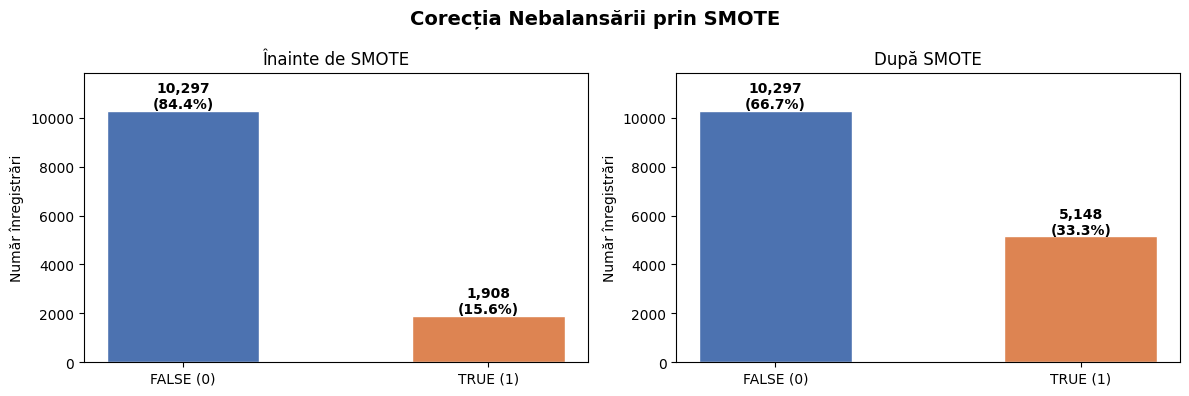

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Corecția Nebalansării prin SMOTE', fontsize=14, fontweight='bold')
 
before = pd.Series(y).value_counts()
after  = pd.Series(y_res).value_counts()
 
for ax, data, title in zip(axes, [before, after], ['Înainte de SMOTE', 'După SMOTE']):
    ax.bar(['FALSE (0)', 'TRUE (1)'], [data[0], data[1]], color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Număr înregistrări')
    for i, v in enumerate([data[0], data[1]]):
        pct = v / data.sum() * 100
        ax.text(i, v + 100, f'{v:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(before[0], after[0]) * 1.15)
 
plt.tight_layout()
plt.show()

-   Dupa SMOTE, raport 1:2